# EM, gradient, and MAP fitting strategies

When to use EM vs gradient maximum-likelihood, how a MAP prior trades bias for variance on small data, and what alternative E-steps (annealed, hard) buy and cost. For the fitting API itself, see the fitting_and_estimation tutorial.


## The latent-variable likelihood and the EM objective

Many models introduce latent variables $z$ (a mixture component, a hidden state) so that the complete-data
density $p(x,z\mid\theta)$ is simple while the observed-data density requires a sum or integral,
$$p(x\mid\theta) = \int p(x,z\mid\theta)\,dz.$$
Maximizing the observed log-likelihood $\ell(\theta)=\sum_i \log p(x_i\mid\theta)$ directly is hard
because the log sits outside the integral. Expectation-Maximization (EM) sidesteps this.

For any distribution $q(z)$ over the latent variable, Jensen's inequality gives the evidence lower bound
(ELBO)
$$\log p(x\mid\theta) \;\ge\; \underbrace{\mathbb E_{q}\!\big[\log p(x,z\mid\theta)\big] + \mathcal H(q)}_{\textstyle \mathcal F(q,\theta)},$$
with $\mathcal H(q)$ the entropy of $q$. The gap is exactly a Kullback-Leibler divergence:
$$\log p(x\mid\theta) - \mathcal F(q,\theta) = \mathrm{KL}\!\big(q(z)\,\big\|\,p(z\mid x,\theta)\big) \ge 0.$$
EM is coordinate ascent on $\mathcal F$: the E-step maximizes over $q$, the M-step over $\theta$.
- E-step: $q^{t+1} = p(z\mid x,\theta^t)$, which sets the KL gap to zero, so $\mathcal F=\ell$ there.
- M-step: $\theta^{t+1} = \arg\max_\theta \mathbb E_{q^{t+1}}[\log p(x,z\mid\theta)]$, the expected
  complete-data log-likelihood (the familiar $Q$ function).

## Why EM never decreases the likelihood

Theorem (monotone ascent). Each EM iteration satisfies $\ell(\theta^{t+1}) \ge \ell(\theta^t)$.

Proof. After the E-step the bound is tight: $\mathcal F(q^{t+1},\theta^t) = \ell(\theta^t)$, because the
KL gap is zero when $q^{t+1}=p(z\mid x,\theta^t)$. The M-step increases the bound in $\theta$:
$\mathcal F(q^{t+1},\theta^{t+1}) \ge \mathcal F(q^{t+1},\theta^t)$. And the bound never exceeds the
likelihood: $\ell(\theta^{t+1}) \ge \mathcal F(q^{t+1},\theta^{t+1})$. Chaining the three,
$$\ell(\theta^{t+1}) \ge \mathcal F(q^{t+1},\theta^{t+1}) \ge \mathcal F(q^{t+1},\theta^{t})
   = \ell(\theta^t). \qquad\blacksquare$$

Theorem (fixed points are stationary). If $\theta^\star$ is a fixed point of EM in the interior of the
parameter space, then $\nabla_\theta \ell(\theta^\star)=0$.

Proof sketch. At a fixed point the M-step leaves $\theta$ unchanged, so
$\nabla_\theta \mathbb E_{p(z\mid x,\theta^\star)}[\log p(x,z\mid\theta)]\big|_{\theta^\star}=0$. A short
calculation (the Fisher identity) shows this gradient equals $\nabla_\theta\ell(\theta^\star)$, so the
observed-data score vanishes. $\quad\blacksquare$

Monotone ascent guarantees convergence of the likelihood values, but only to a stationary point. EM does
not promise the global maximum, and the next section shows two ways it can disappoint.

## MAP estimation as penalized likelihood

Definition (MAP). The maximum a posteriori estimate maximizes the posterior, equivalently a penalized
log-likelihood,
$$\hat\theta_{\mathrm{MAP}} = \arg\max_\theta\ \ell(\theta) + \log\pi(\theta).$$
With a conjugate prior the penalty adds pseudo-counts, so MAP is the same arithmetic as MLE on augmented
data. The prior trades a little bias for a large reduction in variance when $n$ is small, and it can
regularize away the degeneracies below. EM carries over unchanged: add $\log\pi(\theta)$ to the M-step
objective.

## Counterexamples: local maxima and an unbounded likelihood

Local optima. The mixture log-likelihood is generally multimodal, so EM converges to whichever basin its
initialization falls into. Two starts can yield two different fitted models, both stationary points, only
one of them global. This is why mixle offers multiple restarts (`best_of`) and informed
initializations rather than a single run.

An unbounded likelihood. For a Gaussian mixture the observed-data likelihood is not bounded above. Put
one component's mean exactly on a data point, $\mu_k = x_1$, and let its variance $\sigma_k^2\to 0$. That
component's density at $x_1$ is $(2\pi\sigma_k^2)^{-1/2}\to\infty$, so the likelihood diverges. The MLE
therefore does not exist: there are spurious infinite spikes at every data point. EM can be drawn toward
one of these, collapsing a component onto a single observation. The standard fixes are a prior or
penalty on the variances (MAP), a floor on $\sigma^2$, or restarts that avoid the collapsed region, all
of which mixle supports. We illustrate both phenomena below.

In [1]:
import io
import time

import numpy as np
import matplotlib.pyplot as plt

from mixle.stats import (GaussianDistribution, MixtureDistribution,
                        GaussianEstimator, MixtureEstimator,
                        seq_encode, seq_log_density_sum)
from mixle.inference.estimation import optimize
from mixle.inference.gradient_fit import fit_mle, fit_map
from mixle.inference.em import AnnealedEM, HardEM, MonteCarloEM, StandardEM
from mixle.inference.priors import normal_gamma

%matplotlib inline
np.random.seed(0)

## 1. Same answer, three roads

Here is a clean, well-separated two-component Gaussian mixture. We sample 400 points and fit
it three ways:

* `optimize(...)` - the default, which is EM;
* `fit_mle(..., optimizer='lbfgs')` - gradient maximum likelihood with L-BFGS;
* `fit_mle(..., optimizer='adam')` - gradient maximum likelihood with Adam.

All three are climbing the same log-likelihood surface. They should land at essentially the
same value.


In [2]:
truth = MixtureDistribution(
    [GaussianDistribution(-2.0, 1.0), GaussianDistribution(2.0, 1.0)],
    [0.5, 0.5])
data = truth.sampler(seed=1).sample(400)

# A common, deliberately-imperfect starting model used by every fitter below,
# so the comparison is apples-to-apples.
init = MixtureDistribution(
    [GaussianDistribution(-0.5, 1.0), GaussianDistribution(0.5, 1.0)],
    [0.5, 0.5])

# seq_encode produces a chunked encoding that the gradient fitters consume directly.
enc = seq_encode(data, model=truth)
print('encoded %d observations' % len(data))

encoded 400 observations


`fit_mle` returns `(fitted_model, final_log_likelihood)`. Passing `return_result=True`
instead returns a richer `GradientFitResult` that carries the full per-iteration `history`,
which we use below to draw convergence curves. `optimize` prints its progress to a stream; we
capture that stream and parse out the log-likelihood per iteration.


In [3]:
def em_history(data, init_model, max_its=60):
    'Run default EM via optimize and recover its per-iteration log-likelihood.'
    buf = io.StringIO()
    est = MixtureEstimator([GaussianEstimator(), GaussianEstimator()])
    t0 = time.perf_counter()
    fitted = optimize(data, est, max_its=max_its, prev_estimate=init_model,
                      out=buf, print_iter=1)
    dt = time.perf_counter() - t0
    hist = []
    for line in buf.getvalue().splitlines():
        # lines look like: Iteration 5: ln[p_mat(Data|Model)]=-8.95e+02, ...
        if 'ln[p_mat(Data|Model)]=' in line:
            chunk = line.split('ln[p_mat(Data|Model)]=')[1]
            hist.append(float(chunk.split(',')[0]))
    return fitted, np.asarray(hist), dt


def grad_history(enc, init_model, optimizer, max_its=120, lr=0.05):
    'Run fit_mle and return (model, history, wall_time).'
    t0 = time.perf_counter()
    res = fit_mle(enc, init_model, max_its=max_its, lr=lr,
                  optimizer=optimizer, return_result=True)
    dt = time.perf_counter() - t0
    return res.model, np.asarray(res.history), dt


em_model, em_hist, em_dt = em_history(data, init)
lbfgs_model, lbfgs_hist, lbfgs_dt = grad_history(enc, init, 'lbfgs')
adam_model, adam_hist, adam_dt = grad_history(enc, init, 'adam', max_its=200)

for name, model in [('EM', em_model), ('L-BFGS', lbfgs_model), ('Adam', adam_model)]:
    _, ll = seq_log_density_sum(enc, model)
    mus = sorted(round(c.mu, 3) for c in model.components)
    print('%-7s  final log-lik = %10.4f   means = %s' % (name, ll, mus))

EM       final log-lik =  -819.3711   means = [-2.115, 1.957]
L-BFGS   final log-lik =  -819.3711   means = [-2.115, 1.957]
Adam     final log-lik =  -819.3716   means = [-2.113, 1.959]


Three different algorithms, one optimum: all of them recover means near $-2$ and $+2$ and
agree on the log-likelihood to a few decimal places. EM and L-BFGS reach it in a handful of
iterations; Adam (a first-order method with a fixed step size) takes more steps but gets
there too. Let's look at the convergence curves and the wall-clock cost.


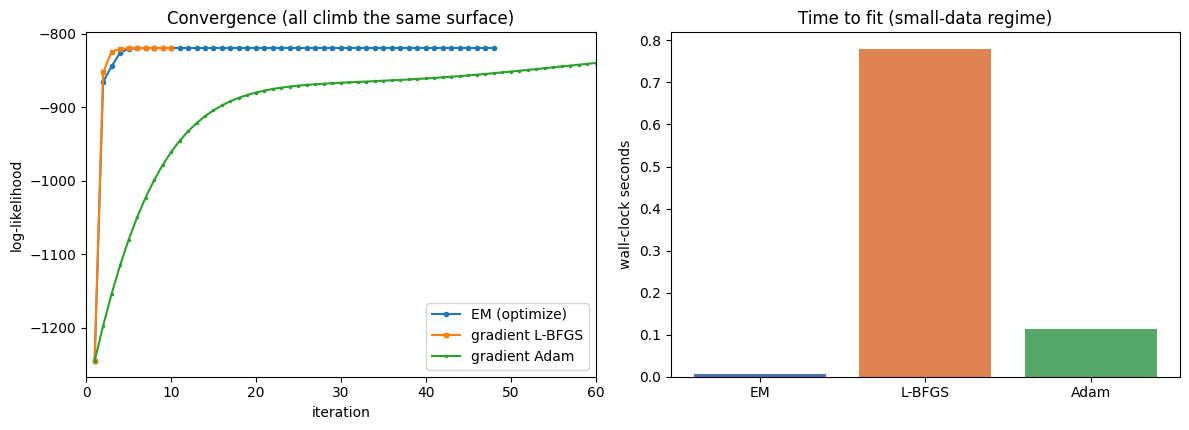

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(np.arange(1, len(em_hist) + 1), em_hist, 'o-', ms=3, label='EM (optimize)')
ax1.plot(np.arange(1, len(lbfgs_hist) + 1), lbfgs_hist, 's-', ms=3, label='gradient L-BFGS')
ax1.plot(np.arange(1, len(adam_hist) + 1), adam_hist, '.-', ms=3, label='gradient Adam')
ax1.set_xlabel('iteration')
ax1.set_ylabel('log-likelihood')
ax1.set_title('Convergence (all climb the same surface)')
ax1.set_xlim(0, 60)
ax1.legend()

names = ['EM', 'L-BFGS', 'Adam']
times = [em_dt, lbfgs_dt, adam_dt]
ax2.bar(names, times, color=['#4c72b0', '#dd8452', '#55a868'])
ax2.set_ylabel('wall-clock seconds')
ax2.set_title('Time to fit (small-data regime)')
plt.tight_layout()

Reading the picture. EM needs no learning rate and converges quadratically near the
optimum, so on a model with a closed-form M-step it is usually both the fastest and the most
foolproof choice - which is exactly why it is the default. L-BFGS, a quasi-Newton method, is
also fast. Adam's fixed-step first-order updates wander a bit before settling.

So why ever leave EM? Because gradient fitting gives you things EM cannot:

* Optimizer control - learning rate, optimizer choice, early stopping, gradient clipping.
* No closed-form M-step required. EM's M-step needs an analytic update for each component.
  When a sub-model has no conjugate update (a custom likelihood, a neural-network-parameterized
  emission, a hard constraint), autograd still produces gradients and `fit_mle` still fits it.
* A direct path to priors. Maximizing log-likelihood plus a log-prior is a one-line change
  for a gradient method, which is exactly the next section.


## 2. MAP regularization: rescuing a tiny dataset

Maximum likelihood has a notorious failure mode for Gaussian mixtures: with few points, a
component can wrap itself tightly around a handful of observations, driving its variance toward
zero and its likelihood toward $+\infty$. The "fit" is a spike, not a distribution.

We reproduce this with just 30 points from the same mixture (a seed chosen to make the
pathology obvious), starting from a symmetric initialization.


In [5]:
small = truth.sampler(seed=8).sample(30)
enc_small = seq_encode(small, model=truth)
init_small = MixtureDistribution(
    [GaussianDistribution(-1.0, 1.0), GaussianDistribution(1.0, 1.0)],
    [0.5, 0.5])

mle_small, _ = fit_mle(enc_small, init_small, max_its=400, lr=0.05, optimizer='lbfgs')
print('Maximum-likelihood fit on 30 points:')
for c in mle_small.components:
    print('   mu = % .3f   sigma^2 = %.3f' % (c.mu, c.sigma2))
print('   (true variance of every component is 1.0)')

Maximum-likelihood fit on 30 points:
   mu = -2.122   sigma^2 = 0.478
   mu =  1.880   sigma^2 = 0.318
   (true variance of every component is 1.0)


One component's variance has collapsed well below the true value of $1.0$: maximum
likelihood is over-trusting a small sample. The cure is a prior on the parameters.

The conjugate prior for a Gaussian's (mean, variance) pair is the Normal-Gamma distribution.
`fit_map` maximizes the log-posterior - log-likelihood plus log-prior - instead of the bare
log-likelihood. Two knobs control it:

* `prior_strength` scales how much the prior counts relative to the data. It behaves like a
  number of pseudo-observations: `prior_strength=0` reduces `fit_map` exactly to `fit_mle`,
  and larger values pull the fit toward the prior mean. This is the classic bias-variance dial.
* `priors=` lets you pass an explicit conjugate prior (e.g. `normal_gamma(...)`) instead of the
  default weakly-informative one.

We fit two MAP models: one with just `prior_strength`, and one with an explicit `normal_gamma`
prior centered at $0$ with a unit-scale variance belief.


In [6]:
map_small, _ = fit_map(enc_small, init_small, prior_strength=8.0,
                       max_its=400, lr=0.05, optimizer='lbfgs')

ng = normal_gamma(mu0=0.0, kappa=1.0, alpha=2.0, beta=1.0)
shared_ng = {'family': 'aligned', 'prior': ng,                     # 0.8.0: broadcasting one prior
              'alignment_receipt': {'mode': 'broadcast',            # across components is explicit
                                    'rationale': 'one conjugate prior shared by every component'}}
map_ng, _ = fit_map(enc_small, init_small, priors=shared_ng, prior_strength=5.0,
                    max_its=400, lr=0.05, optimizer='lbfgs')

print('prior used for the explicit fit:', ng, '\n')
for name, model in [('MLE', mle_small), ('MAP (prior_strength=8)', map_small),
                    ('MAP (normal_gamma)', map_ng)]:
    var = sorted(round(c.sigma2, 3) for c in model.components)
    print('%-26s variances = %s' % (name, var))

prior used for the explicit fit: NormalGammaPrior(mu0=0.0, kappa=1.0, alpha=2.0, beta=1.0) 

MLE                        variances = [0.318, 0.478]
MAP (prior_strength=8)     variances = [0.657, 0.811]
MAP (normal_gamma)         variances = [0.553, 0.761]


Both MAP fits keep the variances near the true value of $1.0$ instead of letting one
collapse. The prior acts as a small number of imaginary, well-behaved observations that the
data must outvote - with only 30 real points it cannot, so the fit stays sane. With thousands
of points the same prior would be drowned out and MAP would converge to ML, which is the
desired behavior: regularization that fades as evidence accumulates.

Let's see the densities.


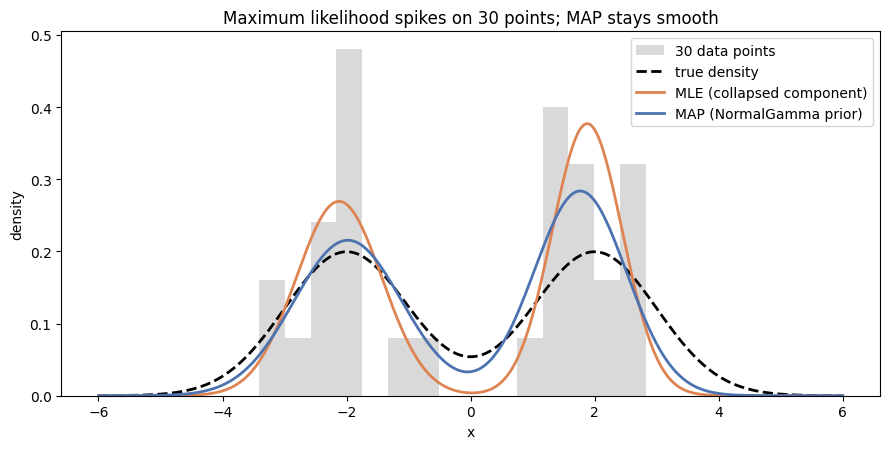

In [7]:
xs = np.linspace(-6, 6, 400)

def mix_density(model, xs):
    return np.array([model.density(x) for x in xs])

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(small, bins=15, density=True, color='0.85', label='30 data points')
ax.plot(xs, mix_density(truth, xs), 'k--', lw=2, label='true density')
ax.plot(xs, mix_density(mle_small, xs), color='#dd8452', lw=2,
        label='MLE (collapsed component)')
ax.plot(xs, mix_density(map_ng, xs), color='#4c72b0', lw=2,
        label='MAP (NormalGamma prior)')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title('Maximum likelihood spikes on 30 points; MAP stays smooth')
ax.legend()
plt.tight_layout()

The orange ML curve shows the tell-tale narrow spike of an over-confident component; the
blue MAP curve tracks the true density. Same data, same optimizer, same number of iterations -
the only difference is a conjugate prior worth a few pseudo-observations.

To sweep the dial explicitly, watch the smallest fitted variance climb back toward $1.0$ as
`prior_strength` grows.


prior_strength =   0.0   min variance = 0.318  (== MLE)
prior_strength =   1.0   min variance = 0.365
prior_strength =   3.0   min variance = 0.459
prior_strength =   8.0   min variance = 0.657
prior_strength =  20.0   min variance = 0.879


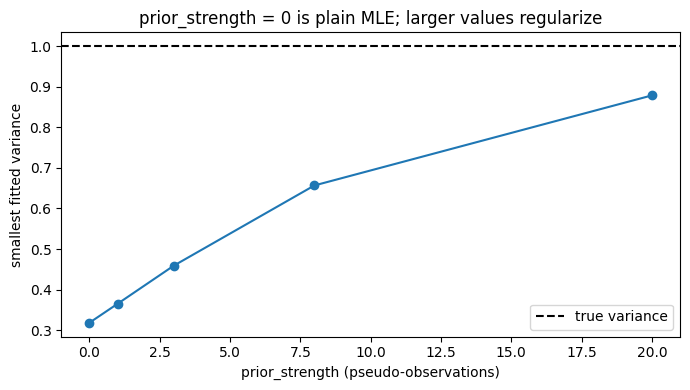

In [8]:
strengths = [0.0, 1.0, 3.0, 8.0, 20.0]
min_vars = []
for s in strengths:
    fm, _ = fit_map(enc_small, init_small, prior_strength=s,
                    max_its=400, lr=0.05, optimizer='lbfgs')
    min_vars.append(min(c.sigma2 for c in fm.components))

for s, v in zip(strengths, min_vars):
    tag = '  (== MLE)' if s == 0.0 else ''
    print('prior_strength = %5.1f   min variance = %.3f%s' % (s, v, tag))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strengths, min_vars, 'o-')
ax.axhline(1.0, color='k', ls='--', label='true variance')
ax.set_xlabel('prior_strength (pseudo-observations)')
ax.set_ylabel('smallest fitted variance')
ax.set_title('prior_strength = 0 is plain MLE; larger values regularize')
ax.legend()
plt.tight_layout()

## 3. EM strategies: swapping the E-step

Mixture likelihoods are riddled with local optima, and ordinary EM is a hill-climber: from a bad
start it climbs the nearest hill and stops. The usual defenses are not a different optimizer -
they are a different E-step plugged into the same monotone EM loop.

`optimize` exposes exactly that through its `strategy=` argument. The M-step, convergence check,
and bookkeeping stay identical; only how responsibilities are computed changes:

* `StandardEM` - the default soft E-step (each point is fractionally shared across
  components by posterior probability).
* `HardEM` - classification EM. Each point is assigned wholesale to its single
  most-likely component (a hard 0/1 responsibility), giving crisp, k-means-like assignments.
* `AnnealedEM` - deterministic annealing. It runs the E-step at a temperature that you
  schedule as a list. Internally the log-responsibilities are divided by the temperature, so
  `temperature > 1` flattens them (every component shares credit, smoothing the landscape) and
  the schedule then cools back toward ordinary EM at `temperature = 1`.

First, let's see what swapping the E-step does, on a model already fit to three well-separated
clusters. We compare the soft posterior responsibilities against the hard 0/1 ones.


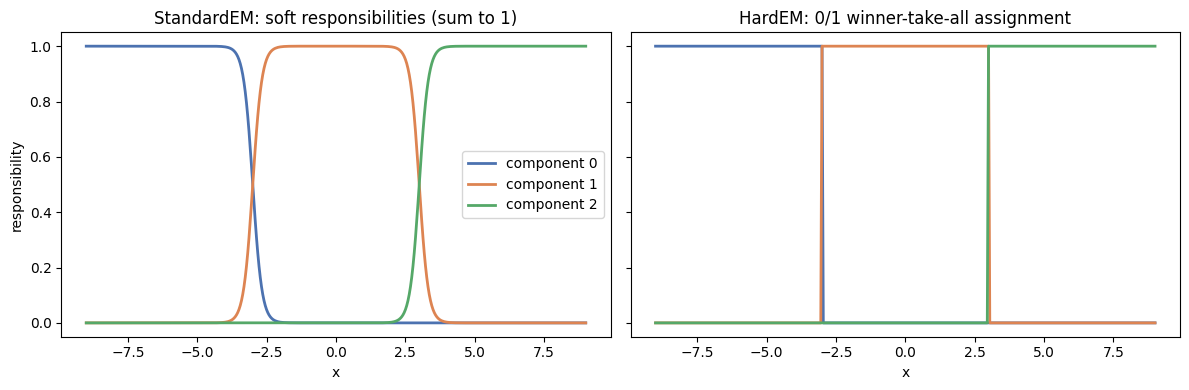

In [9]:
truth3 = MixtureDistribution(
    [GaussianDistribution(-6.0, 1.0),
     GaussianDistribution(0.0, 1.0),
     GaussianDistribution(6.0, 1.0)],
    [1/3, 1/3, 1/3])
data3 = truth3.sampler(seed=1).sample(600)
enc3 = seq_encode(data3, model=truth3)
true_means = np.array([-6.0, 0.0, 6.0])

# model.posterior(x) returns the soft responsibility vector for a single point.
grid = np.linspace(-9, 9, 400)
soft = np.array([truth3.posterior(x) for x in grid])
hard = (soft == soft.max(axis=1, keepdims=True)).astype(float)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for k, color in enumerate(['#4c72b0', '#dd8452', '#55a868']):
    axa.plot(grid, soft[:, k], color=color, lw=2, label='component %d' % k)
    axb.plot(grid, hard[:, k], color=color, lw=2)
axa.set_title("StandardEM: soft responsibilities (sum to 1)")
axb.set_title("HardEM: 0/1 winner-take-all assignment")
axa.set_xlabel('x'); axb.set_xlabel('x')
axa.set_ylabel('responsibility')
axa.legend()
plt.tight_layout()

The soft E-step blends components smoothly in the overlap regions; the hard E-step draws
sharp decision boundaries. That single choice is what each strategy changes - everything else in
`optimize` is shared.

Does a different E-step help you escape local optima? It depends, and it is worth being
precise rather than hand-wavy. We run a small multi-restart experiment: from many poor random
initializations (all three components bunched near the origin), we count how often each strategy
recovers the true three-cluster structure.


In [10]:
def fit_from(init_model, strategy, max_its=150):
    est = MixtureEstimator([GaussianEstimator() for _ in range(3)])
    model = optimize(data3, est, max_its=max_its, prev_estimate=init_model,
                     out=io.StringIO(), strategy=strategy)
    means = np.array(sorted(c.mu for c in model.components))
    return model, means

def recovered(means):
    return bool(np.allclose(means, true_means, atol=0.7))

strategies = {
    'StandardEM (default)':   lambda: StandardEM(),
    'AnnealedEM (gentle)':    lambda: AnnealedEM([1.3, 1.2, 1.1, 1.0, 1.0, 1.0]),
    'AnnealedEM (too hot)':   lambda: AnnealedEM([3.0, 2.5, 2.0, 1.5, 1.2, 1.0, 1.0, 1.0]),
    'HardEM':                 lambda: HardEM(),
}

rng = np.random.RandomState(0)
n_restarts = 24
wins = {name: 0 for name in strategies}
for _ in range(n_restarts):
    mus = rng.uniform(-1.5, 1.5, size=3)   # a poor init: all near the centre
    init_model = MixtureDistribution(
        [GaussianDistribution(float(m), 1.0) for m in mus], [1/3, 1/3, 1/3])
    for name, make in strategies.items():
        _, means = fit_from(init_model, make())
        wins[name] += int(recovered(means))

print('True-structure recovery over %d poor random restarts:\n' % n_restarts)
for name in strategies:
    print('   %-22s %2d / %d' % (name, wins[name], n_restarts))

True-structure recovery over 24 poor random restarts:

   StandardEM (default)   24 / 24
   AnnealedEM (gentle)    24 / 24
   AnnealedEM (too hot)    0 / 24
   HardEM                 12 / 24


Two honest lessons fall out of this, and both matter more than a contrived "annealing always
wins" demo:

1. On clean, well-separated Gaussian mixtures, the default soft EM is already very strong.
   Don't reach for a fancy strategy reflexively - the default earns its place.
2. The annealing temperature is a real dial with a real failure mode. A gentle schedule
   (peaking around 1.3) tracks the default; a too-hot schedule melts all the components
   together early and the cooling cannot pull them back apart, so it recovers far less often.
   HardEM's crisp assignments are more brittle to poor initializations here.

So `strategy=` is a genuine lever, but like a learning rate it must be set with judgement. Let's
visualize the collapse directly: the same poor init, fit with the gentle vs. the too-hot schedule.


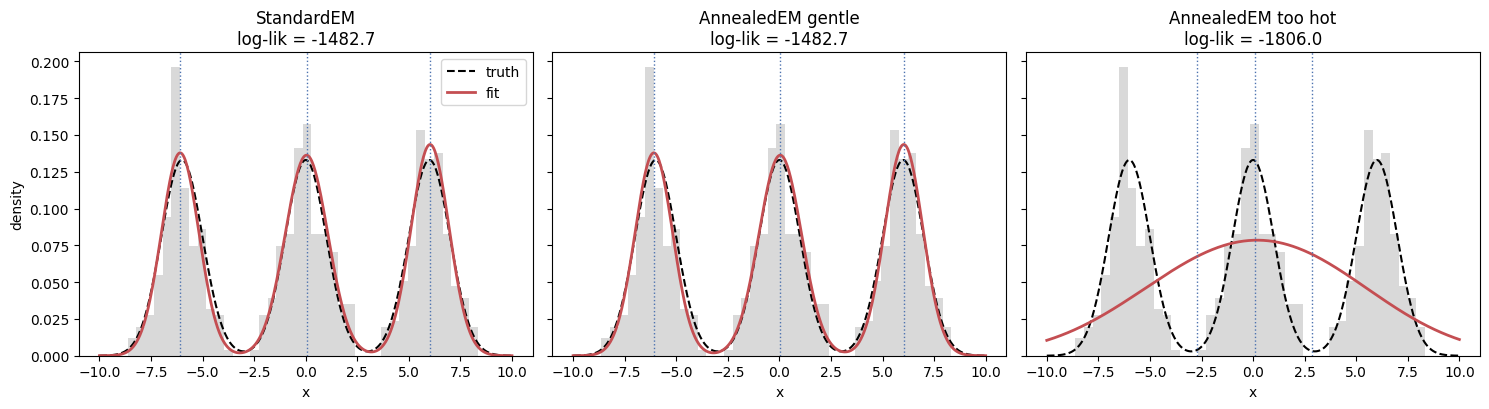

In [11]:
poor_init = MixtureDistribution(
    [GaussianDistribution(-0.4, 1.0),
     GaussianDistribution(0.0, 1.0),
     GaussianDistribution(0.4, 1.0)],
    [1/3, 1/3, 1/3])

m_default, _ = fit_from(poor_init, StandardEM())
m_gentle, _  = fit_from(poor_init, AnnealedEM([1.3, 1.2, 1.1, 1.0, 1.0, 1.0]))
m_hot, _     = fit_from(poor_init, AnnealedEM([3.0, 2.5, 2.0, 1.5, 1.2, 1.0, 1.0, 1.0]))

xs3 = np.linspace(-10, 10, 500)
panels = [('StandardEM', m_default), ('AnnealedEM gentle', m_gentle),
          ('AnnealedEM too hot', m_hot)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (name, model) in zip(axes, panels):
    ax.hist(data3, bins=40, density=True, color='0.85')
    ax.plot(xs3, [truth3.density(x) for x in xs3], 'k--', lw=1.5, label='truth')
    ax.plot(xs3, [model.density(x) for x in xs3], color='#c44e52', lw=2, label='fit')
    for c in model.components:
        ax.axvline(c.mu, color='#4c72b0', ls=':', lw=1)
    _, ll = seq_log_density_sum(enc3, model)
    ax.set_title(name + '\n' + 'log-lik = %.1f' % ll)
    ax.set_xlabel('x')
axes[0].set_ylabel('density')
axes[0].legend()
plt.tight_layout()

The dotted blue lines mark the fitted component means. The default and the gentle schedule
spread their three components across the three clusters; the too-hot schedule leaves them
huddled near the centre with inflated variances - a vivid picture of over-annealing.

`mixle.utils.em` ships more strategies than we exercised here - `MonteCarloEM` (a stochastic
E-step that samples assignments, useful when the posterior is intractable),
`GeneralizedEM`, and others - all plugging into the same `optimize` loop through `strategy=`.
The takeaway is the seam, not any single winner: you can change how responsibilities are
formed without touching the rest of the fitting machinery.


## 4. When to use which

| Method | How to call it | Reach for it when... |
| --- | --- | --- |
| EM (default) | `optimize(data, estimator)` | You want a robust, learning-rate-free fit and your model has a closed-form M-step (most exponential-family distributions). This is the right default. |
| Gradient ML | `fit_mle(enc, model, optimizer=...)` | You need optimizer control (LR schedules, early stopping) or a sub-model has no closed-form M-step (custom or neural-parameterized likelihoods). |
| Gradient MAP | `fit_map(enc, model, prior_strength=...)` | Data are scarce and ML overfits (variance collapse, extreme weights). A conjugate prior regularizes; `prior_strength=0` recovers ML. |
| AnnealedEM | `optimize(..., strategy=AnnealedEM([...]))` | The likelihood is rough and the default keeps landing in local optima. Smooths early then cools - but the schedule is a tunable dial (too hot collapses the mixture). |
| HardEM | `optimize(..., strategy=HardEM())` | You want crisp, k-means-style 0/1 assignments. Faster per step, but more brittle to poor initializations. |
| MonteCarloEM / others | `optimize(..., strategy=MonteCarloEM(...))` | The E-step posterior is intractable and must be approximated by sampling. |

The throughline. All of these optimize the same objective family - log-likelihood, or
log-posterior when a prior is present. EM and its strategy variants share one monotone loop and
swap only the E-step; the gradient fitters trade that closed-form loop for autograd and the
freedom it brings. Start with the default, and reach for the others when the data or the model
gives you a specific reason to.


## EM has local optima - use multiple restarts

EM only finds a local maximum, and on mixtures the likelihood surface is multi-modal: a single random start frequently lands in a bad basin. The standard remedy is many restarts, keep the best (or smart initialization). We fit a poorly-separated two-component mixture from 60 random initializations and look at the distribution of final log-likelihoods - it is bimodal, and only some runs find the good optimum.


Iteration 23: ln[p_mat(Data|Model)]=-1.860723e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.970389e-10


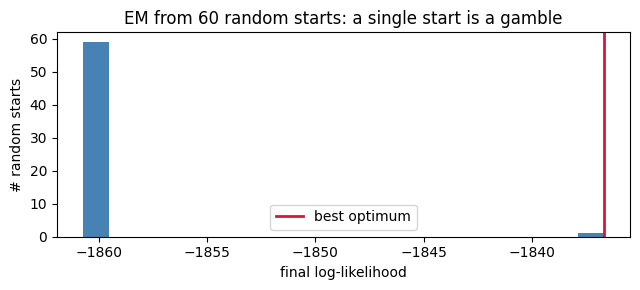

fraction of starts within 1 nat of the best optimum: 0.02


In [12]:
from mixle.stats import GaussianEstimator, MixtureEstimator
from mixle.inference.estimation import optimize
gm = list(np.r_[rng.normal(-1.2, 1.0, 500), rng.normal(1.2, 1.0, 500)])   # heavily overlapping
est = MixtureEstimator([GaussianEstimator(), GaussianEstimator()])
total_ll = lambda m: float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(gm))))
finals = np.array([total_ll(optimize(gm, est, max_its=60, rng=np.random.RandomState(s), print_iter=1000))
                   for s in range(60)])
best = finals.max()
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(finals, bins=20, color='steelblue'); ax.axvline(best, color='crimson', lw=2, label='best optimum')
ax.set_xlabel('final log-likelihood'); ax.set_ylabel('# random starts'); ax.legend()
ax.set_title('EM from 60 random starts: a single start is a gamble')
plt.tight_layout(); plt.show()
print('fraction of starts within 1 nat of the best optimum: %.2f' % np.mean(finals > best - 1.0))

## Illustration: monotone ascent, local optima, and variance collapse

We run a small one-dimensional two-component Gaussian EM. The log-likelihood increases at every
iteration (the monotone-ascent theorem), but different initializations reach different optima (local
maxima), and we show numerically how a component collapsing onto a single point sends the likelihood to
infinity (the unbounded-likelihood counterexample).

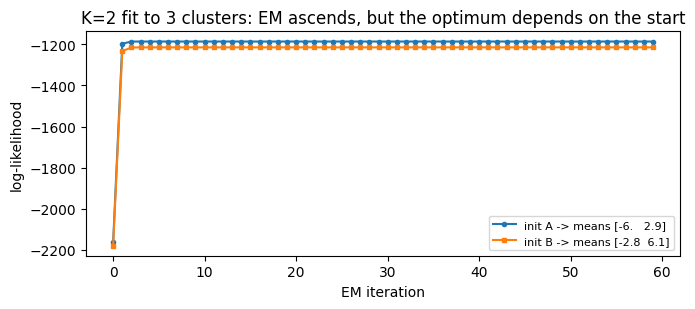

monotone? init A non-decreasing: True
final log-likelihood   init A: -1186.1   init B: -1214.6  (distinct local optima)
a component with mu=x_1 and sigma=1.00 contributes log-density -0.92 at x_1 (diverges as sigma->0)
a component with mu=x_1 and sigma=0.30 contributes log-density 0.29 at x_1 (diverges as sigma->0)
a component with mu=x_1 and sigma=0.10 contributes log-density 1.38 at x_1 (diverges as sigma->0)
a component with mu=x_1 and sigma=0.03 contributes log-density 2.59 at x_1 (diverges as sigma->0)


In [13]:
rng = np.random.RandomState(1)
# three well-separated clusters, but we fit only K=2 -> the likelihood is genuinely multimodal
data = np.r_[rng.normal(-6, 0.7, 150), rng.normal(0, 0.7, 150), rng.normal(6, 0.7, 150)]
def em_1d(data, mu, sd, w, n_iter=60):
    mu, sd, w = map(np.array, (mu, sd, w)); lls = []
    for _ in range(n_iter):
        comp = np.stack([w[k] * np.exp(-0.5 * ((data - mu[k]) / sd[k]) ** 2) / (sd[k] * np.sqrt(2 * np.pi))
                         for k in range(2)], 1)
        tot = comp.sum(1); lls.append(np.log(tot).sum())
        r = comp / tot[:, None]; Nk = r.sum(0)
        mu = (r * data[:, None]).sum(0) / Nk
        sd = np.sqrt((r * (data[:, None] - mu) ** 2).sum(0) / Nk)
        w = Nk / len(data)
    return mu, lls
muA, ll_good = em_1d(data, [-6., 3.], [1., 1.], [.5, .5])   # splits {-6} vs {0, 6}
muB, ll_bad = em_1d(data, [-3., 6.], [1., 1.], [.5, .5])    # splits {-6, 0} vs {6}
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ll_good, 'o-', ms=3, label='init A -> means %s' % np.round(np.sort(muA), 1))
ax.plot(ll_bad, 's-', ms=3, label='init B -> means %s' % np.round(np.sort(muB), 1))
ax.set_xlabel('EM iteration'); ax.set_ylabel('log-likelihood'); ax.legend(fontsize=8)
ax.set_title('K=2 fit to 3 clusters: EM ascends, but the optimum depends on the start')
plt.tight_layout(); plt.show()
print('monotone? init A non-decreasing: %s' % bool(np.all(np.diff(ll_good) >= -1e-8)))
print('final log-likelihood   init A: %.1f   init B: %.1f  (distinct local optima)' % (ll_good[-1], ll_bad[-1]))
for s in [1.0, 0.3, 0.1, 0.03]:
    print('a component with mu=x_1 and sigma=%.2f contributes log-density %.2f at x_1 (diverges as sigma->0)' %
          (s, np.log(1 / (s * np.sqrt(2 * np.pi)))))

## References

- Dempster, A. P., Laird, N. M. & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm (https://doi.org/10.1111/j.2517-6161.1977.tb01600.x). JRSS-B 39(1), 1-38. - the original EM paper.
- Wu, C. F. J. (1983). On the convergence properties of the EM algorithm (https://doi.org/10.1214/aos/1176346060). Ann. Statist. 11(1), 95-103.
- Neal, R. M. & Hinton, G. E. (1998). A view of the EM algorithm that justifies incremental, sparse, and other variants (https://doi.org/10.1007/978-94-011-5014-9_12). In Learning in Graphical Models.
- Ueda, N. & Nakano, R. (1998). Deterministic annealing EM algorithm (https://doi.org/10.1016/S0893-6080(97)00133-0). Neural Networks 11(2), 271-282.
- McLachlan, G. J. & Krishnan, T. (2008). The EM Algorithm and Extensions, 2nd ed. Wiley.


## Exercises and extensions

1. EM as lower-bound maximization. Implement the ELBO/free-energy view of EM (Neal & Hinton): track the variational lower bound and the data log-likelihood across iterations for a Gaussian mixture, and show the E-step closes the gap while the M-step raises the bound. Demonstrate incremental EM (update on mini-batches) and compare convergence speed to batch EM.
2. Bias-variance of MAP, quantified. For a small-sample Gaussian, sweep the prior strength and sample size; over many resamples plot the bias², variance, and MSE of the MAP estimator vs the MLE. Identify the regime where the prior helps and where it hurts, and connect the curve to ridge/shrinkage.
3. Annealed EM escapes saddles. On a poorly-separated mixture, compare standard EM, deterministic-annealing EM (Ueda-Nakano), and many-restart EM over 200 random seeds. Report the distribution of final log-likelihoods and the fraction reaching the global optimum for each strategy; recommend a default. (Builds directly on the initialization lesson in gaussian_mixtures_in_depth.)
4. Custom objective via the gradient path. Add a penalty EM/MLE cannot express in closed form (an L1 sparsity penalty on mixture weights, or a fairness constraint) using `fit_mle`/gradient optimization, and compare the fit, runtime, and convergence to closed-form EM. Discuss when to leave EM for a gradient optimizer.
